In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [2]:
df=pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')

In [3]:
pd.set_option('display.max_columns',None)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
x=df.isna().sum()/len(df)*100
y=x[x>0]
y

LotFrontage     17.739726
Alley           93.767123
MasVnrType       0.547945
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
FireplaceQu     47.260274
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
PoolQC          99.520548
Fence           80.753425
MiscFeature     96.301370
dtype: float64

In [6]:
df.drop(['Id','Alley','PoolQC','Fence','MiscFeature'],axis=1,inplace=True)

# Handling missing values

In [7]:
df['LotFrontage'].fillna(df['LotFrontage'].mean(),inplace=True)
df['MasVnrType'].fillna('None',inplace=True)
df['MasVnrArea'].fillna('0.0',inplace=True)
df['BsmtQual'].fillna('TA',inplace=True)
df['BsmtCond'].fillna('No',inplace=True)
df['BsmtExposure'].fillna('No',inplace=True)
df['BsmtFinType1'].fillna('Unf',inplace=True)
df['BsmtFinType2'].fillna('Unf',inplace=True)
df['Electrical'].fillna('SBrkr',inplace=True)
df['FireplaceQu'].fillna('Gd',inplace=True)
df['GarageType'].fillna('Attchd',inplace=True)
df['GarageYrBlt'].fillna(2005,inplace=True)
df['GarageFinish'].fillna('Unf',inplace=True)
df['GarageQual'].fillna('TA',inplace=True)
df['GarageCond'].fillna('TA',inplace=True)

In [8]:
x=df.isnull().sum()
x[x>0]

Series([], dtype: int64)

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import datetime as dt

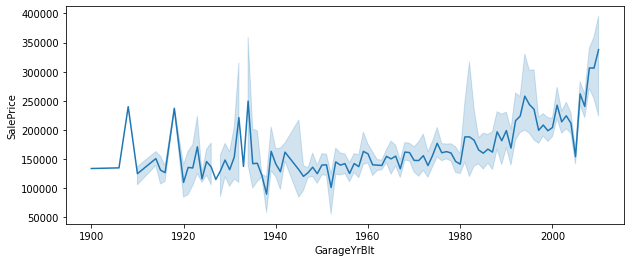

In [10]:
plt.figure(figsize=(10,4))
sns.lineplot(x=df['GarageYrBlt'],y=df['SalePrice'])
plt.show()

In [11]:
x=df.nunique()
x[x<5]

Street          2
LotShape        4
LandContour     4
Utilities       2
LandSlope       3
MasVnrType      4
ExterQual       4
BsmtQual        4
BsmtExposure    4
CentralAir      2
BsmtFullBath    4
BsmtHalfBath    3
FullBath        4
HalfBath        3
KitchenAbvGr    4
KitchenQual     4
Fireplaces      4
GarageFinish    3
PavedDrive      3
dtype: int64

In [12]:
x=df.nunique()
x[x>100]

LotFrontage       111
LotArea          1073
YearBuilt         112
MasVnrArea        328
BsmtFinSF1        637
BsmtFinSF2        144
BsmtUnfSF         780
TotalBsmtSF       721
1stFlrSF          753
2ndFlrSF          417
GrLivArea         861
GarageArea        441
WoodDeckSF        274
OpenPorchSF       202
EnclosedPorch     120
SalePrice         663
dtype: int64

# PreProcessing the data

In [13]:
df['Rating']=(df['OverallQual']+df['OverallCond'])/2
df.drop(['OverallQual','OverallCond'],axis=1,inplace=True)

df['ExterQual']=df['ExterQual'].map({'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1})
df['ExterCond']=df['ExterCond'].map({'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1})
df['ExterRating']=(df['ExterQual']+df['ExterCond'])/2
df.drop(['ExterQual','ExterCond'],axis=1,inplace=True)

df['BsmtQual']=df['BsmtQual'].map({'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NA':0})
df['BsmtCond']=df['BsmtCond'].map({'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NA':0})
df['BsmtRating']=(df['BsmtQual']+df['BsmtCond'])/2
df.drop(['BsmtQual','BsmtCond'],axis=1,inplace=True)

df['BsmtFinType1']=df['BsmtFinType1'].map({'GLQ':6,'ALQ':5,'BLQ':4,'Rec':3,'LwQ':2,'Unf':1,'NA':1})
df['BsmtFinType2']=df['BsmtFinType2'].map({'GLQ':6,'ALQ':5,'BLQ':4,'Rec':3,'LwQ':2,'Unf':1,'NA':1})
df['BsmtFinRating']=(df['BsmtFinType1']+df['BsmtFinType2'])/2
df.drop(['BsmtFinType1','BsmtFinType2'],axis=1,inplace=True)

df['GarageQual']=df['GarageQual'].map({'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NA':0})
df['GarageCond']=df['GarageCond'].map({'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NA':0})
df['GarageRating']=(df['GarageQual']+df['GarageCond'])/2
df.drop(['GarageQual','GarageCond'],axis=1,inplace=True)

df['BsmtExposure']=df['BsmtExposure'].map({'Ad':3,'Gd':2,'Mn':1,'No':0})
df['HeatingQC']=df['HeatingQC'].map({'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NA':0})
df['CentralAir']=df['CentralAir'].map({'Y':1,'N':0})
df['KitchenQual']=df['KitchenQual'].map({'Ex':3,'Gd':2,'TA':1,'Fa':0})
df['FireplaceQu']=df['FireplaceQu'].map({'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1})
df['GarageFinish']=df['GarageFinish'].map({'Fin':3,'Rfn':2,'Unf':1,'NA':0})
df['PavedDrive']=df['PavedDrive'].map({'Y':1,'P':0.5,'N':0})

df.drop(['BsmtFinSF1','BsmtFinSF2','BsmtUnfSF'],axis=1,inplace=True)

df['TotalFlrSF']=df['1stFlrSF']+df['2ndFlrSF']
df.drop(['1stFlrSF','2ndFlrSF'],axis=1,inplace=True)

df['TotalFullBath']=df['BsmtFullBath']+df['FullBath']
df['TotalHalfBath']=df['BsmtHalfBath']+df['HalfBath']
df.drop(['BsmtFullBath','FullBath','BsmtHalfBath','HalfBath'],axis=1,inplace=True)

df['TotalRoom']=df['BedroomAbvGr']+df['KitchenAbvGr']
df.drop(['BedroomAbvGr','KitchenAbvGr','TotRmsAbvGrd'],axis=1,inplace=True)

df['Porch']=df['OpenPorchSF']+df['EnclosedPorch']+df['3SsnPorch']+df['ScreenPorch']
df.drop(['OpenPorchSF','EnclosedPorch','3SsnPorch','ScreenPorch'],axis=1,inplace=True)

df.drop(['Electrical','Heating','Foundation','Functional','GarageType','SaleType','SaleCondition','MasVnrArea'],axis=1,inplace=True)

In [14]:
obj_col=list(df.select_dtypes('O'))
len(obj_col)

17

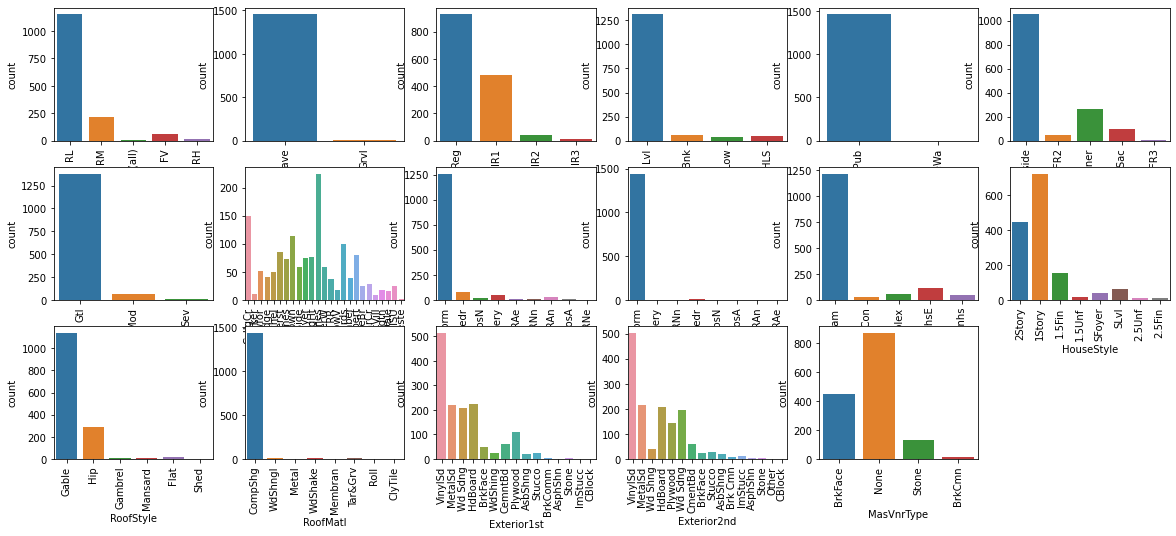

In [15]:
plt.figure(figsize=(20,20))
for i,col in enumerate(obj_col):
    plt.subplot(7,6,i+1)
    sns.countplot(x=df[col])
    plt.xticks(rotation=90)
plt.show()

In [16]:
numeric_col=list(df.select_dtypes('int').columns)
len(numeric_col)

25

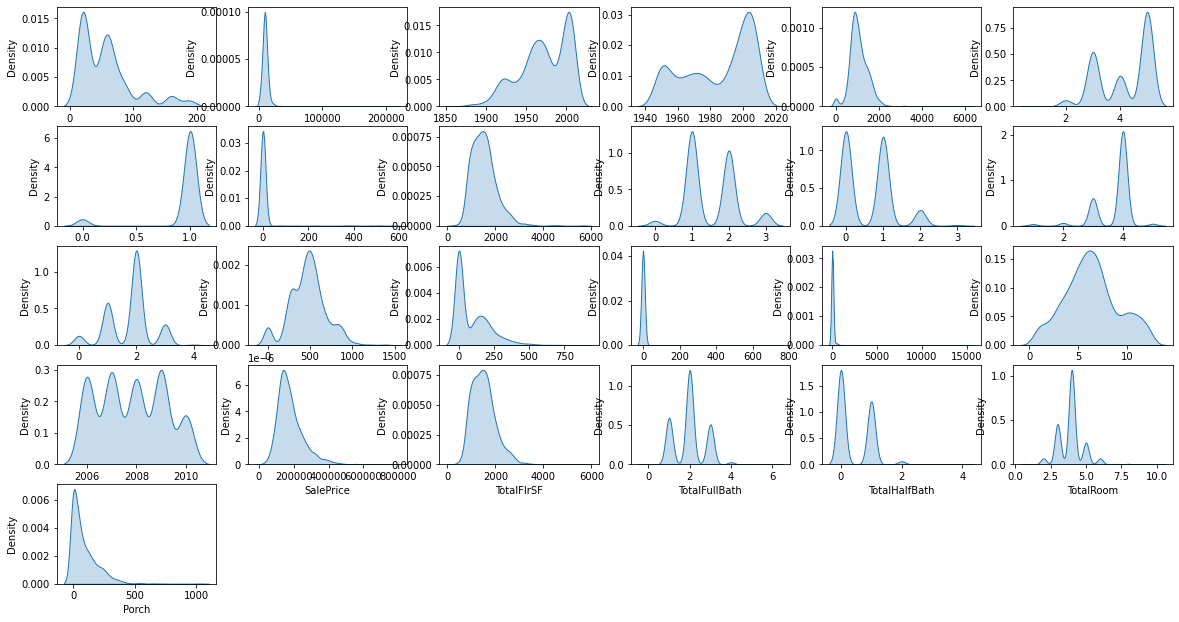

In [17]:
plt.figure(figsize=(20,15))
for i,col in enumerate(numeric_col):
    plt.subplot(7,6,i+1)
    sns.kdeplot(df[col],fill=True)
plt.show()

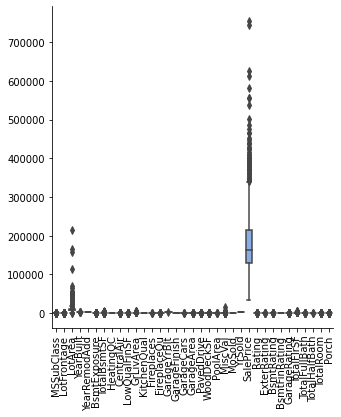

In [18]:
sns.catplot(data=df,kind='box')
plt.xticks(rotation=90)
plt.show()

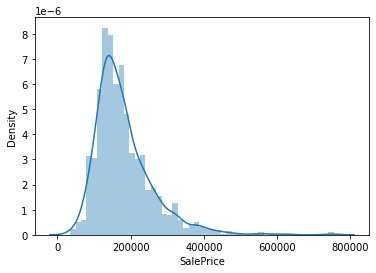

In [19]:
sns.distplot(df['SalePrice'])
plt.show()

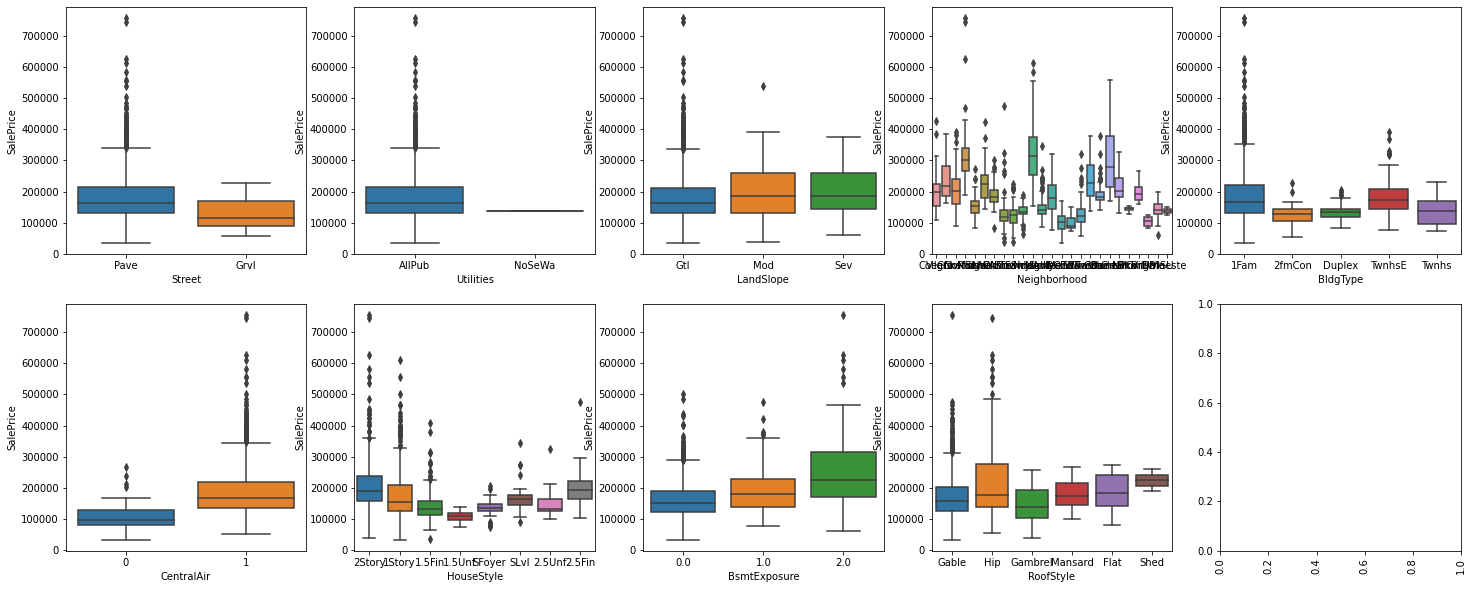

In [20]:
fig,axs=plt.subplots(figsize=(25,10),ncols=5,nrows=2)

sns.boxplot(y=df['SalePrice'],x=df['Street'],ax=axs[0,0])
sns.boxplot(y=df['SalePrice'],x=df['Utilities'],ax=axs[0,1])
sns.boxplot(y=df['SalePrice'],x=df['LandSlope'],ax=axs[0,2])
plt.xticks(rotation=90)
sns.boxplot(y=df['SalePrice'],x=df['Neighborhood'],ax=axs[0,3])
sns.boxplot(y=df['SalePrice'],x=df['BldgType'],ax=axs[0,4])
sns.boxplot(y=df['SalePrice'],x=df['CentralAir'],ax=axs[1,0])
sns.boxplot(y=df['SalePrice'],x=df['HouseStyle'],ax=axs[1,1])
sns.boxplot(y=df['SalePrice'],x=df['BsmtExposure'],ax=axs[1,2])
sns.boxplot(y=df['SalePrice'],x=df['RoofStyle'],ax=axs[1,3])

plt.show()

# Object Column handling

In [21]:
obj_col=df.select_dtypes('object').columns
obj_col

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType'],
      dtype='object')

In [22]:
for i in df[obj_col]:
    print(df[i].value_counts())

RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: MSZoning, dtype: int64
Pave    1454
Grvl       6
Name: Street, dtype: int64
Reg    925
IR1    484
IR2     41
IR3     10
Name: LotShape, dtype: int64
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: LandContour, dtype: int64
AllPub    1459
NoSeWa       1
Name: Utilities, dtype: int64
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: LotConfig, dtype: int64
Gtl    1382
Mod      65
Sev      13
Name: LandSlope, dtype: int64
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: Neighborhood, dtype: int64
Norm      1260
Feedr       81
Artery     

# OneHotEncoding

In [23]:
encoded_data=pd.get_dummies(df[obj_col])

df.drop(obj_col,axis=1,inplace=True)

df=pd.concat([df,encoded_data],axis=1)

# Top 10 highly positive correlated features with Sale Price

In [24]:
#df.corr().style.background_gradient()

corr_matrix=df.corr()
print(pd.DataFrame({'corr':corr_matrix['SalePrice'][:10].sort_values(ascending=False)}))

                  corr
TotalBsmtSF   0.613581
YearBuilt     0.522897
YearRemodAdd  0.507101
HeatingQC     0.427649
BsmtExposure  0.379729
LotFrontage   0.334901
LotArea       0.263843
CentralAir    0.251328
LowQualFinSF -0.025606
MSSubClass   -0.084284


 # Top 10 highly negative correlated features with Sale Price

In [25]:
print(pd.DataFrame({'corr':corr_matrix['SalePrice'][-10:].sort_values(ascending=True)}))

                         corr
MasVnrType_None     -0.367456
Exterior2nd_Wd Sdng -0.161800
Exterior2nd_Plywood -0.052941
MasVnrType_BrkCmn   -0.044394
Exterior2nd_Stucco  -0.042416
Exterior2nd_Wd Shng -0.040329
Exterior2nd_Stone   -0.016754
MasVnrType_BrkFace   0.198191
Exterior2nd_VinylSd  0.306389
MasVnrType_Stone     0.330476


In [26]:
df.head()

,MSSubClass,LotFrontage,LotArea,YearBuilt,YearRemodAdd,BsmtExposure,TotalBsmtSF,HeatingQC,CentralAir,LowQualFinSF,GrLivArea,KitchenQual,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageArea,PavedDrive,WoodDeckSF,PoolArea,MiscVal,MoSold,YrSold,SalePrice,Rating,ExterRating,BsmtRating,BsmtFinRating,GarageRating,TotalFlrSF,TotalFullBath,TotalHalfBath,TotalRoom,Porch,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_AllPub,Utilities_NoSeWa,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Artery,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_ClyTile,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone
0,60,65.0,8450,2003,2003,0.0,856,5,1,0,1710,2,0,4,2003.0,NaN,2,548,1.0,0,0,0,2,2008,208500,6.0,3.5,3.5,3.5,3.0,1710,3,1,4,61,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
1,20,80.0,9600,1976,1976,2.0,1262,5,1,0,1262,1,1,3,1976.0,NaN,2,460,1.0,298,0,0,5,2007,181500,7.0,3.0,3.5,3.0,3.0,1262,2,1,4,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
2,60,68.0,11250,2001,2002,1.0,920,5,1,0,1786,2,1,3,2001.0,NaN,2,608,1.0,0,0,0,9,2008,223500,6.0,3.5,3.5,3.5,3.0,1786,3,1,4,42,0,0,0,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
3,70,60.0,9550,1915,1970,0.0,756,4,1,0,1717,2,1,4,1998.0,1.0,3,642,1.0,0,0,0,2,2006,140000,6.0,3.0,3.5,3.0,3.0,1717,2,0,4,307,0,0,0,1,0,0,1,1,0,0,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,

In [27]:
pip install XGBoost

Note: you may need to restart the kernel to use updated packages.


In [28]:
x=df.drop('SalePrice',axis=1)
y=df['SalePrice']

from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,random_state=3,test_size=0.2)

from xgboost import XGBRegressor
xgb=XGBRegressor(random_state=1,n_estimators=500)
xgb.fit(xtrain,ytrain)

ypred=xgb.predict(xtest)
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

print('Accuracy score:',r2_score(ytest,ypred),'\nRoot Mean Squared Error: ',np.sqrt(mean_squared_error(ytest,ypred)))
print('Training Accuracy',xgb.score(xtrain,ytrain),'\nTesting Accuracy',xgb.score(xtest,ytest))

Accuracy score: 0.7956108048276881 
Root Mean Squared Error:  31768.352800980403
Training Accuracy 0.9999999999591428 
Testing Accuracy 0.7956108048276881


# FeatureImportance

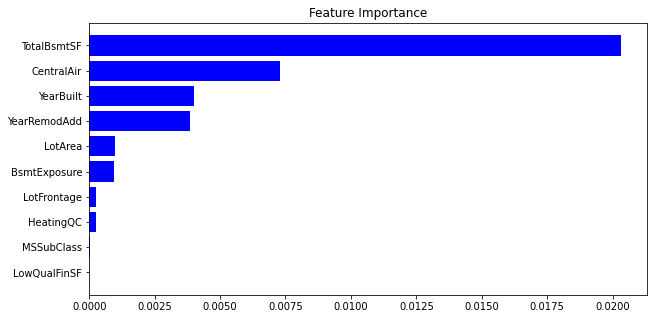

In [29]:
importances=xgb.feature_importances_
indices=np.argsort(importances[:10])
plt.figure(figsize=(10,5))
plt.title('Feature Importance')
plt.barh(range(len(indices)),importances[indices],color='b',align='center')
plt.yticks(range(len(indices)),[x.columns[i] for i in indices])
plt.show()

In [30]:
x=df[['TotalFlrSF','KitchenQual','BsmtRating','TotalFullBath','Rating','TotalBsmtSF','GrLivArea','CentralAir','Fireplaces',\
      'YearBuilt','YearRemodAdd','LotArea','HeatingQC','LotFrontage']]

# XGBRegressor

In [31]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,random_state=3,test_size=0.2)
xgb=XGBRegressor(learning_rate=0.10,n_estimators=40,max_depth=6)
xgb.fit(xtrain,ytrain)
ypred=xgb.predict(xtest)

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print('Accuracy score:',r2_score(ytest,ypred),'\nRoot Mean Squared Error: ',np.sqrt(mean_squared_error(ytest,ypred))) 
print('Training Accuracy',xgb.score(xtrain,ytrain),'\nTesting Accuracy',xgb.score(xtest,ytest))

Accuracy score: 0.8361835329107961 
Root Mean Squared Error:  28440.97680367828
Training Accuracy 0.9737113118143215 
Testing Accuracy 0.8361835329107961


In [32]:
x=x.fillna(-1)

# RandomForestRegressor

In [33]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,random_state=5,test_size=0.2)

from sklearn.ensemble import RandomForestRegressor
rfr=RandomForestRegressor(max_depth=5,n_estimators=60,min_samples_leaf=10,min_samples_split=2)
rfr.fit(xtrain,ytrain)
ypred=rfr.predict(xtest)

print('Accuracy score:',r2_score(ytest,ypred),'\nRoot Mean Squared Error: ',np.sqrt(mean_squared_error(ytest,ypred)))
print('Training Accuracy',rfr.score(xtrain,ytrain),'\nTesting Accuracy',rfr.score(xtest,ytest))

Accuracy score: 0.833491598071048 
Root Mean Squared Error:  32873.09883828267
Training Accuracy 0.8594696474186251 
Testing Accuracy 0.833491598071048


In [34]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,random_state=5,test_size=0.2)

from sklearn.ensemble import GradientBoostingRegressor
gbc=GradientBoostingRegressor(learning_rate=0.2,n_estimators=50,max_depth=6)
gbc.fit(xtrain,ytrain)
gbc_ypred=gbc.predict(xtest)

print('Accuracy score:',r2_score(ytest,gbc_ypred),'\nRoot Mean Squared Error: ',np.sqrt(mean_squared_error(ytest,gbc_ypred)))
print('Training Accuracy',gbc.score(xtrain,ytrain),'\nTesting Accuracy',gbc.score(xtest,ytest))

Accuracy score: 0.9128029770472558 
Root Mean Squared Error:  23788.847267921294
Training Accuracy 0.9932371788658576 
Testing Accuracy 0.9128029770472558


In [35]:
from sklearn.model_selection import cross_val_score
cv=cross_val_score(xgb,x,y,cv=5,scoring='neg_mean_squared_error')
cv

array([-7.30993576e+08, -1.18353705e+09, -9.63811735e+08, -3.96381417e+08,
       -9.37692764e+08])

In [36]:
test=pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')

In [37]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,None,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [38]:
test.drop(['Id','Alley','PoolQC','Fence','MiscFeature'],axis=1,inplace=True)
test['LotFrontage'].fillna(test['LotFrontage'].mean(),inplace=True)
test['MasVnrType'].fillna('None',inplace=True)
test['MasVnrArea'].fillna('0.0',inplace=True)
test['BsmtQual'].fillna('TA',inplace=True)
test['BsmtCond'].fillna('No',inplace=True)
test['BsmtExposure'].fillna('No',inplace=True)
test['BsmtFinType1'].fillna('Unf',inplace=True)
test['BsmtFinType2'].fillna('Unf',inplace=True)
test['Electrical'].fillna('SBrkr',inplace=True)
test['FireplaceQu'].fillna('Gd',inplace=True)
test['GarageType'].fillna('Attchd',inplace=True)
test['GarageYrBlt'].fillna(2005,inplace=True)
test['GarageFinish'].fillna('Unf',inplace=True)
test['GarageQual'].fillna('TA',inplace=True)
test['GarageCond'].fillna('TA',inplace=True)

test['Rating']=(test['OverallQual']+test['OverallCond'])/2
test.drop(['OverallQual','OverallCond'],axis=1,inplace=True)
test['ExterQual']=test['ExterQual'].map({'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1})
test['ExterCond']=test['ExterCond'].map({'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1})

test['ExterRating']=(test['ExterQual']+test['ExterCond'])/2
test.drop(['ExterQual','ExterCond'],axis=1,inplace=True)
test['BsmtQual']=test['BsmtQual'].map({'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NA':0})
test['BsmtCond']=test['BsmtCond'].map({'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NA':0})

test['BsmtRating']=(test['BsmtQual']+test['BsmtCond'])/2
test.drop(['BsmtQual','BsmtCond'],axis=1,inplace=True)
test['BsmtFinType1']=test['BsmtFinType1'].map({'GLQ':6,'ALQ':5,'BLQ':4,'Rec':3,'LwQ':2,'Unf':1,'NA':1})
test['BsmtFinType2']=test['BsmtFinType2'].map({'GLQ':6,'ALQ':5,'BLQ':4,'Rec':3,'LwQ':2,'Unf':1,'NA':1})

test['BsmtFinRating']=(test['BsmtFinType1']+test['BsmtFinType2'])/2
test.drop(['BsmtFinType1','BsmtFinType2'],axis=1,inplace=True)
test['GarageQual']=test['GarageQual'].map({'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NA':0})
test['GarageCond']=test['GarageCond'].map({'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NA':0})
test['GarageRating']=(test['GarageQual']+test['GarageCond'])/2
test.drop(['GarageQual','GarageCond'],axis=1,inplace=True)

test['BsmtExposure']=test['BsmtExposure'].map({'Ad':3,'Gd':2,'Mn':1,'No':0})
test['HeatingQC']=test['HeatingQC'].map({'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NA':0})
test['CentralAir']=test['CentralAir'].map({'Y':1,'N':0})
test['KitchenQual']=test['KitchenQual'].map({'Ex':3,'Gd':2,'TA':1,'Fa':0})
test['FireplaceQu']=test['FireplaceQu'].map({'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1})
test['GarageFinish']=test['GarageFinish'].map({'Fin':3,'Rfn':2,'Unf':1,'NA':0})
test['PavedDrive']=test['PavedDrive'].map({'Y':1,'P':0.5,'N':0})

test.drop(['BsmtFinSF1','BsmtFinSF2','BsmtUnfSF'],axis=1,inplace=True)

test['TotalFlrSF']=test['1stFlrSF']+test['2ndFlrSF']
test.drop(['1stFlrSF','2ndFlrSF'],axis=1,inplace=True)

test['TotalFullBath']=test['BsmtFullBath']+test['FullBath']
test['TotalHalfBath']=test['BsmtHalfBath']+test['HalfBath']
test.drop(['BsmtFullBath','FullBath','BsmtHalfBath','HalfBath'],axis=1,inplace=True)

test['TotalRoom']=test['BedroomAbvGr']+test['KitchenAbvGr']
test.drop(['BedroomAbvGr','KitchenAbvGr','TotRmsAbvGrd'],axis=1,inplace=True)

test['Porch']=test['OpenPorchSF']+test['EnclosedPorch']+test['3SsnPorch']+test['ScreenPorch']
test.drop(['OpenPorchSF','EnclosedPorch','3SsnPorch','ScreenPorch'],axis=1,inplace=True)

test.drop(['Electrical','Heating','Foundation','Functional','GarageType','SaleType','SaleCondition','MasVnrArea'],axis=1,inplace=True)

In [39]:
obj_col=test.select_dtypes('object').columns
obj_col

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType'],
      dtype='object')

In [40]:
test_encoded_data=pd.get_dummies(test[obj_col])

test.drop(obj_col,axis=1,inplace=True)

test=pd.concat([test,test_encoded_data],axis=1)

In [41]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Columns: 151 entries, MSSubClass to MasVnrType_Stone
dtypes: float64(16), int64(18), uint8(117)
memory usage: 554.4 KB


In [42]:
x=test[['TotalFlrSF','KitchenQual','BsmtRating','TotalFullBath','Rating','TotalBsmtSF','GrLivArea','CentralAir','Fireplaces',\
      'YearBuilt','YearRemodAdd','LotArea','HeatingQC','LotFrontage']]


In [43]:
x.isnull().sum()

TotalFlrSF        0
KitchenQual       1
BsmtRating       45
TotalFullBath     2
Rating            0
TotalBsmtSF       1
GrLivArea         0
CentralAir        0
Fireplaces        0
YearBuilt         0
YearRemodAdd      0
LotArea           0
HeatingQC         0
LotFrontage       0
dtype: int64

In [44]:
x.fillna(-1,inplace=True)

In [45]:
x.head(2)

,TotalFlrSF,KitchenQual,BsmtRating,TotalFullBath,Rating,TotalBsmtSF,GrLivArea,CentralAir,Fireplaces,YearBuilt,YearRemodAdd,LotArea,HeatingQC,LotFrontage
0,896,1.0,3.0,1.0,5.5,882.0,896,1,0,1961,1961,11622,3,80.0
1,1329,2.0,3.0,1.0,6.0,1329.0,1329,1,0,1958,1958,14267,3,81.0


In [46]:
prediction=gbc.predict(x)
test=pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')

In [47]:
output=pd.DataFrame({'Id':test['Id'],'SalePrice':prediction})
output.head()

,Id,SalePrice
0,1461,123173.530793
1,1462,161927.587460
2,1463,179564.556681
3,1464,177802.032196
4,1465,185588.811999


In [48]:
output.to_csv('Submission2.csv',index=False)

In [49]:
s=pd.read_csv('/kaggle/working/Submission2.csv')
s.head()

,Id,SalePrice
0,1461,123173.530793
1,1462,161927.587460
2,1463,179564.556681
3,1464,177802.032196
4,1465,185588.811999


# Thankyou! :)